# N1 · 组装 mini-VLA: backbone + 动作头

> 配套 11.2-L1/L4 · VLA = 感知 backbone (真实里 = M10 VLM) + 动作头。
> 先 import M10 的 mini-VLM 确认它是 backbone 插槽, 再用 `mini_vla` 在 toy 控制任务上组装
> 「backbone + 离散动作头」, 训练 + rollout。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import mini_vla as vla
import toy_env as env, action_serialize as ser   # M11.1 共享 (mini_vla 已加进 path)
import numpy as np, torch

## 1. 确认 backbone 插槽: M10 的 mini-VLM 就是 VLA 的感知核

In [2]:
# import M10.3 的 mini-VLM, 确认它是「图像+指令 → 理解特征」的感知核 (VLA backbone 插槽)
import sys
from pathlib import Path
m10 = Path.cwd().parents[1] / "vlm-training-recipe" / "src"
sys.path.insert(0, str(m10))
try:
    import mini_vlm
    print("✅ M10 mini-VLM 可用 = VLA 的 backbone 插槽 (真实 VLA 用它编码图像+指令)")
    print("   真实 VLA: backbone=VLM(M10) → 特征 → 动作头(本专题)")
    print("   玩具 VLA: backbone=状态MLP   → 特征 → 动作头 (结构/角色完全一致)")
except Exception as e:
    print("M10 mini_vlm 不可用, 不影响玩具 (玩具用状态编码 backbone):", e)

✅ M10 mini-VLM 可用 = VLA 的 backbone 插槽 (真实 VLA 用它编码图像+指令)
   真实 VLA: backbone=VLM(M10) → 特征 → 动作头(本专题)
   玩具 VLA: backbone=状态MLP   → 特征 → 动作头 (结构/角色完全一致)


## 2. 组装 mini-VLA (backbone + 离散动作头) 并模仿专家

In [3]:
torch.manual_seed(0)
S, A = env.make_demos(n=400, seed=0)
model = vla.build_mini_vla(head="discrete")
losses = vla.train_vla(model, S, A, epochs=400)
print(f"mini-VLA (离散头) 训练: loss {losses[0]:.3f} → {losses[-1]:.3f}")
print("结构: 状态 → backbone(MLP) → 特征 → 离散动作头(9类) → 动作 token")

mini-VLA (离散头) 训练: loss 2.195 → 0.025
结构: 状态 → backbone(MLP) → 特征 → 离散动作头(9类) → 动作 token


## 3. rollout: 组装的 mini-VLA 能走到目标吗

mini-VLA 成功率: 1.00


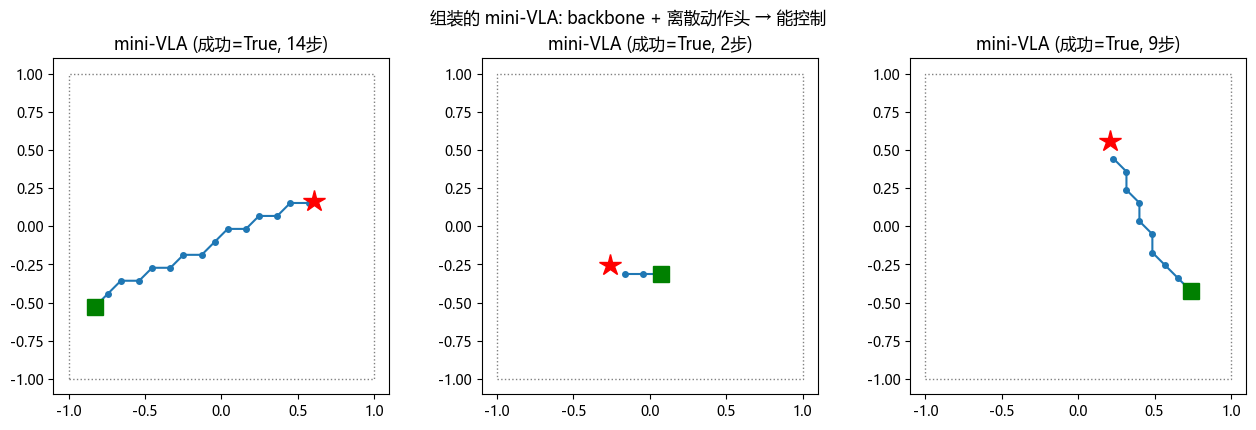

→ backbone + 动作头 = 一个能用的 VLA。真实里把 backbone 换成 M10 VLM、状态换成图像即可。


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
pol = vla.make_policy(model)
sr = env.eval_policy(pol, n_episodes=200)
print(f"mini-VLA 成功率: {sr:.2f}")
fig, axes = plt.subplots(1, 3, figsize=(13,4.2))
for ax, seed in zip(axes, [3,6,9]):
    ok, steps, traj = env.rollout(pol, seed=seed, record=True); traj=np.array(traj)
    ax.plot(traj[:,0], traj[:,1], '-o', ms=4)
    ax.plot(traj[0,0], traj[0,1], 'gs', ms=12); ax.plot(traj[0,2], traj[0,3], 'r*', ms=16)
    ax.add_patch(plt.Rectangle((-1,-1),2,2,fill=False,ls=':',ec='gray'))
    ax.set_title(f'mini-VLA (成功={ok}, {steps}步)'); ax.set_aspect('equal')
plt.suptitle('组装的 mini-VLA: backbone + 离散动作头 → 能控制'); plt.tight_layout(); plt.show()
print("→ backbone + 动作头 = 一个能用的 VLA。真实里把 backbone 换成 M10 VLM、状态换成图像即可。")

## 3. 反思
你组装了一个 mini-VLA (backbone + 动作头) 并让它控制。带走:
- **VLA = 两阶段**: backbone (理解, =M10 VLM) + 动作头 (决定动作)。
- backbone 你 M10 已造好; VLA 只是把 VQA 输出层换成动作头 (RT-2 做法)。
- mini-VLA → OpenVLA 只差规模 + 真实数据, 机制一样。
下一步 N2: 动作头的第一个选择 —— 离散 vs 连续, 各有什么代价?